# DPO alignment — results analysis

Analyzes the two experiments under `align/dpo_out/runs/`:

- **`base_full_20260710`** — one full run at the default config (β=0.1, lr=1e-4, bs=16, r=8, all 53k train pairs, `--heldout-eval` on).
- **`sweep_20260710`** — 30-trial Optuna study over β × lr × lora_rank × batch_size on an 8k-pair subset, objective = val `reward_acc`.

Three questions:
1. **Did alignment improve?** — de novo Spearman(pseudo-LL, ΔG), policy vs base.
2. **How far did the model move from the base?** — kl_drift.
3. **Did the sweep find the right hyperparams, and can we scale to full training?**

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 10})

# find repo root (dir containing align/dpo_out) regardless of where the kernel starts
ROOT = Path.cwd()
while not (ROOT / 'align' / 'dpo_out').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
RUNS = ROOT / 'align' / 'dpo_out' / 'runs'
DB = ROOT / 'align' / 'dpo_out' / 'optuna_study.db'
BASE_EXP, SWEEP_EXP = 'base_full_20260710', 'sweep_20260710'
print('root:', ROOT)

def load_history(exp):
    """Concatenate every history.json under runs/<exp>/ into one tidy frame."""
    frames = []
    for hist in sorted((RUNS / exp).rglob('history.json')):
        h = json.loads(hist.read_text())
        if not h:
            continue
        d = pd.DataFrame(h)
        d['run'] = hist.parent.name
        frames.append(d)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

idx = pd.read_csv(ROOT / 'align' / 'dpo_out' / 'runs_index.csv')
print('runs_index rows:', len(idx))

root: /home/arjun/genai/esm/rl_esm
runs_index rows: 34


## 1. Did alignment improve? (base run)

`denovo_spearman_base` is the frozen ESM-C's rank correlation with true ΔG on 3000 held-out **de novo** sequences — folds never seen in training. `denovo_spearman_policy` is the same for the aligned model. This is the real generalization test.

In [2]:
b = load_history(BASE_EXP).sort_values('step').reset_index(drop=True)
train = b[b.step > 0]  # step 0 is the untrained baseline (policy == ref)

base_rho = b.denovo_spearman_base.iloc[0]
peak = train.loc[train.denovo_spearman_policy.idxmax()]
best_acc_row = train.loc[train.reward_acc.idxmax()]  # this is what best/ is saved on
final = b.iloc[-1]

print(f'base ESM-C de novo Spearman      : {base_rho:+.3f}   (no stability signal)')
print(f'aligned policy — PEAK            : {peak.denovo_spearman_policy:+.3f}   @ step {int(peak.step)}  (kl_drift {peak.kl_drift:.0f})')
print(f'aligned policy — final           : {final.denovo_spearman_policy:+.3f}   @ step {int(final.step)}  (kl_drift {final.kl_drift:.0f})')
print(f'aligned policy — at best/ ckpt   : {best_acc_row.denovo_spearman_policy:+.3f}   @ step {int(best_acc_row.step)}  (chosen by reward_acc={best_acc_row.reward_acc:.3f})')
print()
print(f'>> DPO turned a {base_rho:+.3f} correlation into a peak of {peak.denovo_spearman_policy:+.3f} — a large alignment gain.')
print(f'>> But the de novo peak (step {int(peak.step)}) != the reward_acc peak (step {int(best_acc_row.step)}),')
print(f'   and the FINAL model ({final.denovo_spearman_policy:+.3f}) is well below the peak — over-optimization.')

base ESM-C de novo Spearman      : -0.053   (no stability signal)
aligned policy — PEAK            : +0.572   @ step 2600  (kl_drift -214)
aligned policy — final           : +0.406   @ step 3324  (kl_drift -254)
aligned policy — at best/ ckpt   : +0.524   @ step 1000  (chosen by reward_acc=0.894)

>> DPO turned a -0.053 correlation into a peak of +0.572 — a large alignment gain.
>> But the de novo peak (step 2600) != the reward_acc peak (step 1000),
   and the FINAL model (+0.406) is well below the peak — over-optimization.


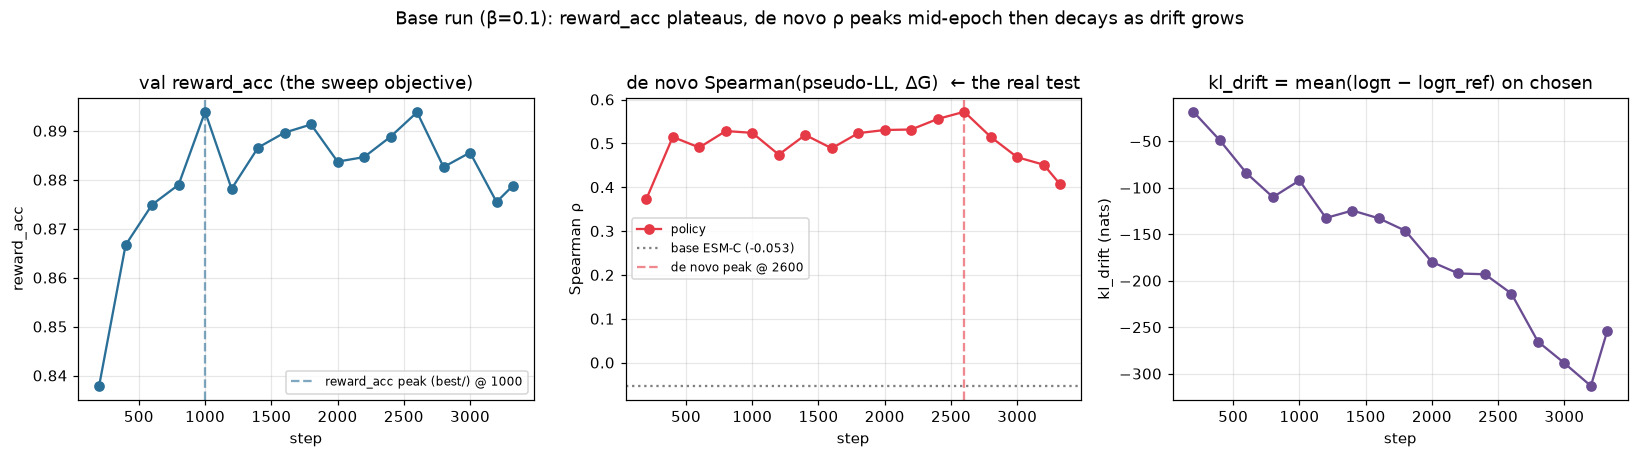

In [3]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].plot(train.step, train.reward_acc, 'o-', color='#2a6f97')
ax[0].axvline(best_acc_row.step, ls='--', color='#2a6f97', alpha=0.6, label=f'reward_acc peak (best/) @ {int(best_acc_row.step)}')
ax[0].set(title='val reward_acc (the sweep objective)', xlabel='step', ylabel='reward_acc')
ax[0].legend(fontsize=8)

ax[1].plot(train.step, train.denovo_spearman_policy, 'o-', color='#e63946', label='policy')
ax[1].axhline(base_rho, ls=':', color='gray', label=f'base ESM-C ({base_rho:+.3f})')
ax[1].axvline(peak.step, ls='--', color='#e63946', alpha=0.6, label=f'de novo peak @ {int(peak.step)}')
ax[1].set(title='de novo Spearman(pseudo-LL, ΔG)  ← the real test', xlabel='step', ylabel='Spearman ρ')
ax[1].legend(fontsize=8)

ax[2].plot(train.step, train.kl_drift, 'o-', color='#6a4c93')
ax[2].set(title='kl_drift = mean(logπ − logπ_ref) on chosen', xlabel='step', ylabel='kl_drift (nats)')

fig.suptitle('Base run (β=0.1): reward_acc plateaus, de novo ρ peaks mid-epoch then decays as drift grows', y=1.03)
fig.tight_layout(); plt.show()

**Read-off:**
- **Alignment clearly improved** — de novo ρ goes from ≈0 (base) to a peak ≈0.57.
- **`reward_acc` tracks the real metric only loosely.** Within this fixed-β run it correlates moderately (next cell), but it plateaus early (~0.89) while de novo ρ swings 0.37→0.57, and its argmax (step 1000) misses the de novo peak (step 2600). So `best/`'s reward_acc criterion doesn't land on the best de novo model — and, as §3 shows, *across* β it's actively misleading.
- **More training past the de novo peak hurts** — classic DPO over-optimization: kl_drift keeps growing, de novo ρ falls back to 0.41.

In [4]:
# How good a proxy is reward_acc for the real (de novo) metric?
from scipy.stats import spearmanr, pearsonr
r_s = spearmanr(train.reward_acc, train.denovo_spearman_policy).statistic
r_p = pearsonr(train.reward_acc, train.denovo_spearman_policy).statistic
print(f'within the base run (β fixed): corr(reward_acc, de novo ρ) = Spearman {r_s:+.2f}, Pearson {r_p:+.2f} — moderate.')
print(f'BUT the reward_acc argmax (step {int(best_acc_row.step)}) misses the de novo argmax (step {int(peak.step)}),')
print('and ACROSS β (the sweep, next section) the link inverts: a lower β lifts reward_acc while runaway')
print('drift destroys de novo ρ. So reward_acc is an OK within-run signal but a misleading search objective.')

within the base run (β fixed): corr(reward_acc, de novo ρ) = Spearman +0.60, Pearson +0.72 — moderate.
BUT the reward_acc argmax (step 1000) misses the de novo argmax (step 2600),
and ACROSS β (the sweep, next section) the link inverts: a lower β lifts reward_acc while runaway
drift destroys de novo ρ. So reward_acc is an OK within-run signal but a misleading search objective.


## 2. How far did the model move from the base? (drift)

`kl_drift = mean(logπ − logπ_ref)` on chosen sequences. The DPO loss only constrains the *difference* (chosen − rejected), so nothing stops the absolute pseudo-LL of both from sliding far from the reference — that slide is the drift.

In [5]:
print(f'base run final kl_drift: {final.kl_drift:.0f} nats on chosen (pseudo-LL dropped ~{abs(final.kl_drift):.0f} vs the frozen base).')
print(f'reward_margin grew {train.reward_margin.iloc[0]:.1f} -> {train.reward_margin.iloc[-1]:.1f} while drift grew {train.kl_drift.iloc[0]:.0f} -> {train.kl_drift.iloc[-1]:.0f}.')
print('The policy has moved a long way in absolute terms; the useful signal (de novo ρ) saturated well before the drift did.')

base run final kl_drift: -254 nats on chosen (pseudo-LL dropped ~254 vs the frozen base).
reward_margin grew 1.6 -> 6.1 while drift grew -18 -> -254.
The policy has moved a long way in absolute terms; the useful signal (de novo ρ) saturated well before the drift did.


## 3. Did the sweep find the right hyperparams?

The sweep's objective is val `reward_acc` (heldout de novo eval **off** for speed). Watch what that objective rewards.

In [6]:
sw = idx[idx.exp_name == SWEEP_EXP].copy()
sw['pruned'] = sw.best_reward_acc < 0
done = sw[~sw.pruned].copy()
print(f'{len(sw)} trials | {(~sw.pruned).sum()} complete | {sw.pruned.sum()} pruned\n')
cols = ['run_name', 'beta', 'lr', 'lora_rank', 'batch_size', 'best_reward_acc', 'final_kl_drift']
print('TOP 6 by reward_acc (the objective):')
print(done.sort_values('best_reward_acc', ascending=False)[cols].head(6).to_string(index=False))

30 trials | 20 complete | 10 pruned

TOP 6 by reward_acc (the objective):
                                                 run_name     beta       lr  lora_rank  batch_size  best_reward_acc  final_kl_drift
trial029_beta0.02798_lr0.0003889_lora_rank32_batch_size16 0.027982 0.000389         32          16         0.908875     -421.617091
  trial026_beta0.0267_lr0.000416_lora_rank16_batch_size16 0.026705 0.000416         16          16         0.906625     -598.845145
  trial010_beta0.02135_lr0.0004664_lora_rank8_batch_size8 0.021353 0.000466          8           8         0.906000    -1136.196705
 trial024_beta0.0267_lr0.0004184_lora_rank16_batch_size16 0.026704 0.000418         16          16         0.905250     -791.858682
trial023_beta0.02751_lr0.0004014_lora_rank16_batch_size16 0.027507 0.000401         16          16         0.903625     -850.193530
trial027_beta0.02003_lr0.0004885_lora_rank16_batch_size16 0.020034 0.000488         16          16         0.902500     -926.162969


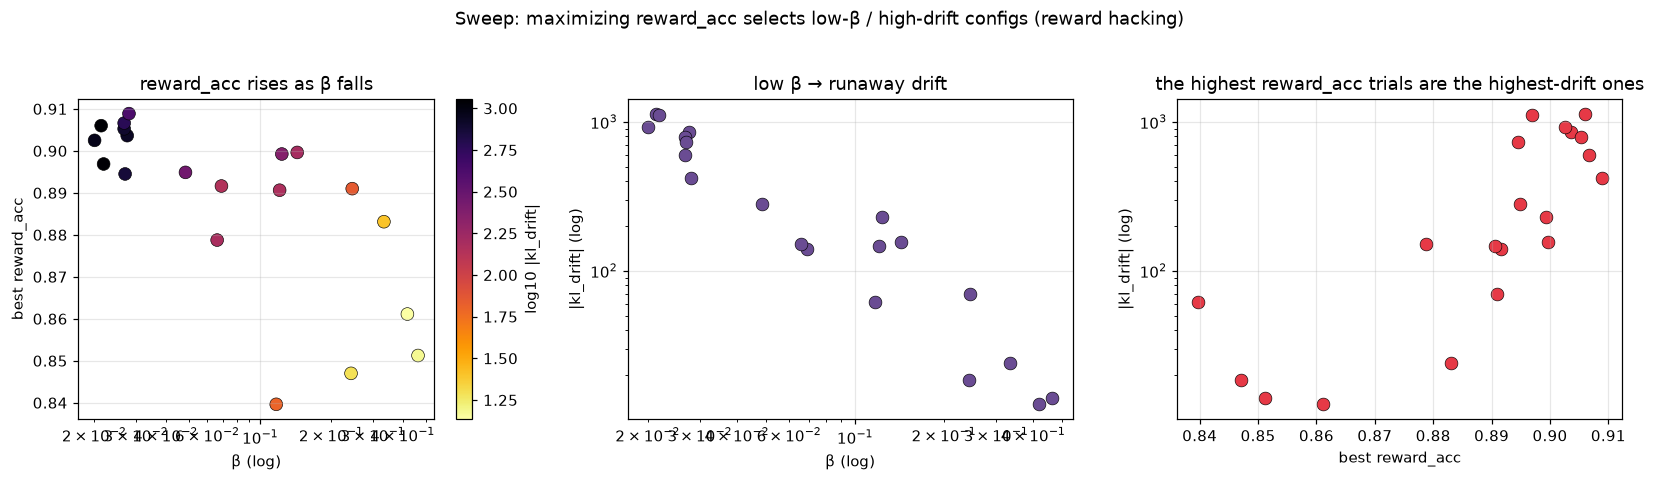

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
d = done

sc = ax[0].scatter(d.beta, d.best_reward_acc, c=np.log10(np.abs(d.final_kl_drift)+1),
                   cmap='inferno_r', s=70, edgecolor='k', linewidth=0.4)
ax[0].set(xscale='log', xlabel='β (log)', ylabel='best reward_acc', title='reward_acc rises as β falls')
plt.colorbar(sc, ax=ax[0], label='log10 |kl_drift|')

ax[1].scatter(d.beta, np.abs(d.final_kl_drift), c='#6a4c93', s=70, edgecolor='k', linewidth=0.4)
ax[1].set(xscale='log', yscale='log', xlabel='β (log)', ylabel='|kl_drift| (log)', title='low β → runaway drift')

ax[2].scatter(d.best_reward_acc, np.abs(d.final_kl_drift), c='#e63946', s=70, edgecolor='k', linewidth=0.4)
ax[2].set(yscale='log', xlabel='best reward_acc', ylabel='|kl_drift| (log)',
          title='the highest reward_acc trials are the highest-drift ones')

fig.suptitle('Sweep: maximizing reward_acc selects low-β / high-drift configs (reward hacking)', y=1.03)
fig.tight_layout(); plt.show()

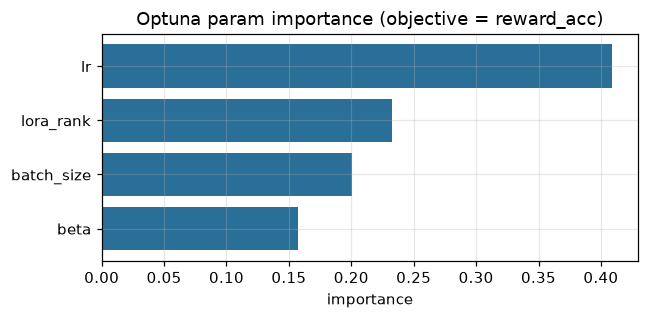

best trial: 29 | reward_acc 0.9089
params     : {'beta': 0.027981561874632653, 'lr': 0.00038886588803917243, 'lora_rank': 32, 'batch_size': 16}

base run reward_acc for reference: 0.894 (β=0.1, full 53k pairs)


In [8]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.load_study(study_name=SWEEP_EXP, storage=f'sqlite:///{DB}')
imp = optuna.importance.get_param_importances(study)

fig, ax = plt.subplots(figsize=(6, 3))
ax.barh(list(imp.keys())[::-1], list(imp.values())[::-1], color='#2a6f97')
ax.set(title='Optuna param importance (objective = reward_acc)', xlabel='importance')
fig.tight_layout(); plt.show()
print('best trial:', study.best_trial.number, '| reward_acc', round(study.best_value, 4))
print('params     :', study.best_trial.params)
print(f"\nbase run reward_acc for reference: {best_acc_row.reward_acc:.3f} (β=0.1, full 53k pairs)")

**Verdict on the sweep — it optimized the wrong thing.**

- The winner (β≈0.028) is **3.6× smaller β** than the base run, chosen because `reward_acc` is monotonically improved by weakening the KL constraint. The top trials carry `kl_drift` down to **−800…−1100** — far past where the base run's de novo ρ already started decaying (~−250).
- The reward_acc gap that separates winner from base (≈0.909 vs 0.894) is **tiny and not comparable** — the sweep val set is an 8k-pair subset, the base uses the full 10.8k, and Section 1 showed reward_acc barely tracks the de novo metric anyway.
- **Conclusion:** the sweep did NOT find hyperparams suited to the real goal (de novo ΔG ranking). It found the reward-hacking corner of the space.

## 4. Can we use it for full-extent training?

**Not the sweep winner as-is.** Scaling β=0.028 to full data (and/or more epochs) would push `kl_drift` even harder and, per the base run's own trajectory, most likely *lower* the de novo ρ. Two concrete fixes before a full run:

1. **Select and stop on the de novo metric, not `reward_acc`.** The base run already shows the real optimum is mid-epoch (step ~2600, ρ≈0.57) — `best/`'s reward_acc criterion missed it, and `last/` is worse. Either add de novo Spearman as the checkpoint/early-stop signal, or eval more frequently and pick the ρ-max checkpoint.
2. **Re-do the search against the real objective** (or at least a KL-penalized one). Options: turn `heldout_eval` on in the sweep and optimize `denovo_spearman_policy`, or keep reward_acc but **constrain β ≥ ~0.1** so trials can't win by drifting.

The cell below writes a corrected full-training config to `align/configs/full_train_config.yaml` — moderate β, more frequent eval, heldout on — as a safer starting point than `best_sweep_config.yaml`.

In [9]:
import yaml
full_cfg = {
    'model': 'biohub/ESMC-300M',
    'train_pairs': 'data/prepared/dpo_pairs_train.csv',
    'val_pairs': 'data/prepared/dpo_pairs_val.csv',
    'epochs': 2,
    'batch_size': 16,
    'beta': 0.1,          # keep the base run's moderate KL constraint (sweep's 0.028 over-drifts)
    'lr': 2.0e-4,         # a notch up from base 1e-4, toward the sweep's better-conditioned region
    'lora_rank': 16,
    'lora_alpha': 16,
    'lora_dropout': 0.0,
    'grad_clip': 1.0,
    'max_pairs': 0,       # full 53k train pairs
    'eval_steps': 100,    # finer, so we can pick the de novo-ρ-max checkpoint
    'heldout_eval': True, # measure the REAL metric during the run
    'heldout_n': 3000,
    'length_norm': False,
    'mask_scoring': False,
    'seed': 0,
}
out = ROOT / 'align' / 'configs' / 'full_train_config.yaml'
out.write_text('# Corrected full-training config (see notebooks/dpo_results_analysis.ipynb §4).\n'
               '# Moderate beta + heldout_eval on; select the checkpoint by de novo Spearman, not reward_acc.\n'
               '#   pixi run python align/train_dpo.py --config align/configs/full_train_config.yaml --exp-name full_v1\n\n'
               + yaml.safe_dump(full_cfg, sort_keys=False))
print('wrote', out)
print(out.read_text())

wrote /home/arjun/genai/esm/rl_esm/align/configs/full_train_config.yaml
# Corrected full-training config (see notebooks/dpo_results_analysis.ipynb §4).
# Moderate beta + heldout_eval on; select the checkpoint by de novo Spearman, not reward_acc.
#   pixi run python align/train_dpo.py --config align/configs/full_train_config.yaml --exp-name full_v1

model: biohub/ESMC-300M
train_pairs: data/prepared/dpo_pairs_train.csv
val_pairs: data/prepared/dpo_pairs_val.csv
epochs: 2
batch_size: 16
beta: 0.1
lr: 0.0002
lora_rank: 16
lora_alpha: 16
lora_dropout: 0.0
grad_clip: 1.0
max_pairs: 0
eval_steps: 100
heldout_eval: true
heldout_n: 3000
length_norm: false
mask_scoring: false
seed: 0



### Summary

| question | answer |
|---|---|
| Did alignment improve? | **Yes, strongly** — de novo Spearman ≈ **−0.05 → +0.57** (peak). |
| How far did it move from base? | **Far** — kl_drift to ≈ **−250** (base run); the sweep's low-β winners hit **−800…−1100**. |
| Did the sweep find the right HPs? | **No** — it maximized `reward_acc`, which rewards low-β / high-drift reward hacking; it never saw the de novo metric. |
| Ready for full-extent training? | **Not with `best_sweep_config.yaml`.** Use a moderate β, turn on heldout eval, and select/stop on de novo ρ. See `full_train_config.yaml`. |